# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan dalam penelitian ini adalah Bank Marketing Dataset yang diperoleh dari platform Kaggle, yaitu sebuah repositori publik yang menyediakan berbagai dataset untuk keperluan analisis data dan pengembangan model machine learning. Dataset tersebut berisi informasi mengenai pelanggan sebuah institusi perbankan yang dihubungi dalam kampanye pemasaran langsung (direct marketing campaign) untuk menawarkan produk deposito berjangka (term deposit). Informasi yang tersedia mencakup berbagai karakteristik pelanggan, seperti usia, pekerjaan, status pernikahan, tingkat pendidikan, saldo rekening, serta riwayat interaksi pelanggan dengan kampanye pemasaran sebelumnya.

Tujuan dari penggunaan dataset ini adalah untuk membangun model klasifikasi yang dapat memprediksi kemungkinan seorang pelanggan akan menerima atau menolak penawaran deposito berdasarkan karakteristik pelanggan dan informasi kampanye pemasaran yang tersedia.

Dataset ini dipilih karena memiliki struktur data yang jelas, jumlah observasi yang cukup, serta kombinasi fitur numerik dan kategorikal yang relevan untuk proses analisis data dan pembangunan model machine learning.

# **2. Import Library**

Pada tahap ini dilakukan proses impor beberapa pustaka (library) Python yang diperlukan dalam proses analisis data dan pembangunan model machine learning. Library yang digunakan antara lain:

- **pandas** untuk membaca dan memanipulasi dataset.
- **numpy** untuk operasi numerik.
- **matplotlib** dan **seaborn** untuk visualisasi data pada tahap Exploratory Data Analysis (EDA).
- **StandardScaler** dari sklearn untuk melakukan normalisasi data numerik pada tahap preprocessing.

Library-library ini akan digunakan pada tahap eksplorasi data, preprocessing, hingga persiapan data sebelum masuk ke tahap pembangunan model.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set(style="whitegrid")

# **3. Memuat Dataset**

## 3. Memuat Dataset

Pada tahap ini dataset akan dimuat ke dalam notebook menggunakan library **pandas**. Dataset yang digunakan merupakan **Bank Marketing Dataset** yang diperoleh dari Kaggle. Dataset ini berisi informasi mengenai karakteristik nasabah serta hasil kampanye pemasaran bank yang menawarkan produk deposito berjangka.

Proses ini dilakukan untuk memastikan dataset dapat terbaca dengan baik sebelum dilakukan analisis lebih lanjut. Setelah dataset berhasil dimuat, beberapa baris awal data akan ditampilkan untuk memahami struktur dataset serta jenis informasi yang tersedia pada setiap kolom.

In [75]:
df = pd.read_csv("../dataset_raw/bank_marketing.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Setelah dataset dimuat berikutnya dilakukan pengecekan ukuran dataset untuk mengetahui jumlah baris dan kolom yang tersedia.

Cek Ukuran Dataset

In [76]:
df.shape

(11162, 17)

Setelah mengetahui ukuran dataset, langkah berikutnya adalah melihat nama kolom yang terdapat pada dataset. 

In [77]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Selain itu, perlu dilakukan pengecekan tipe data pada setiap kolom untuk memahami apakah data berupa numerik atau kategorikal. Informasi ini penting karena akan mempengaruhi proses preprocessing yang akan dilakukan pada tahap selanjutnya.

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### Statistik Deskriptif

In [79]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### Pengecekan Missing Value

In [80]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

### Distribusi Target Variable

Target variable pada dataset ini adalah **deposit**, yang menunjukkan apakah nasabah menerima atau menolak penawaran deposito. Visualisasi distribusi target dilakukan untuk melihat apakah dataset memiliki distribusi kelas yang seimbang atau tidak.

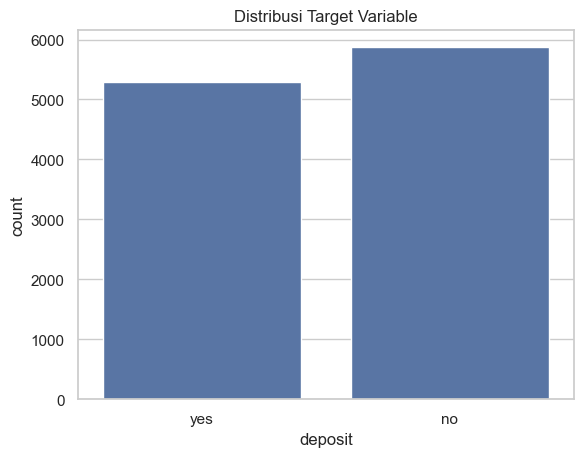

In [81]:
sns.countplot(x='deposit', data=df)
plt.title("Distribusi Target Variable")
plt.show()

### Distribusi Fitur Numerik

Visualisasi distribusi fitur numerik dilakukan untuk memahami sebaran data pada setiap variabel numerik. Informasi ini membantu dalam melihat apakah terdapat skewness atau nilai ekstrem pada data.

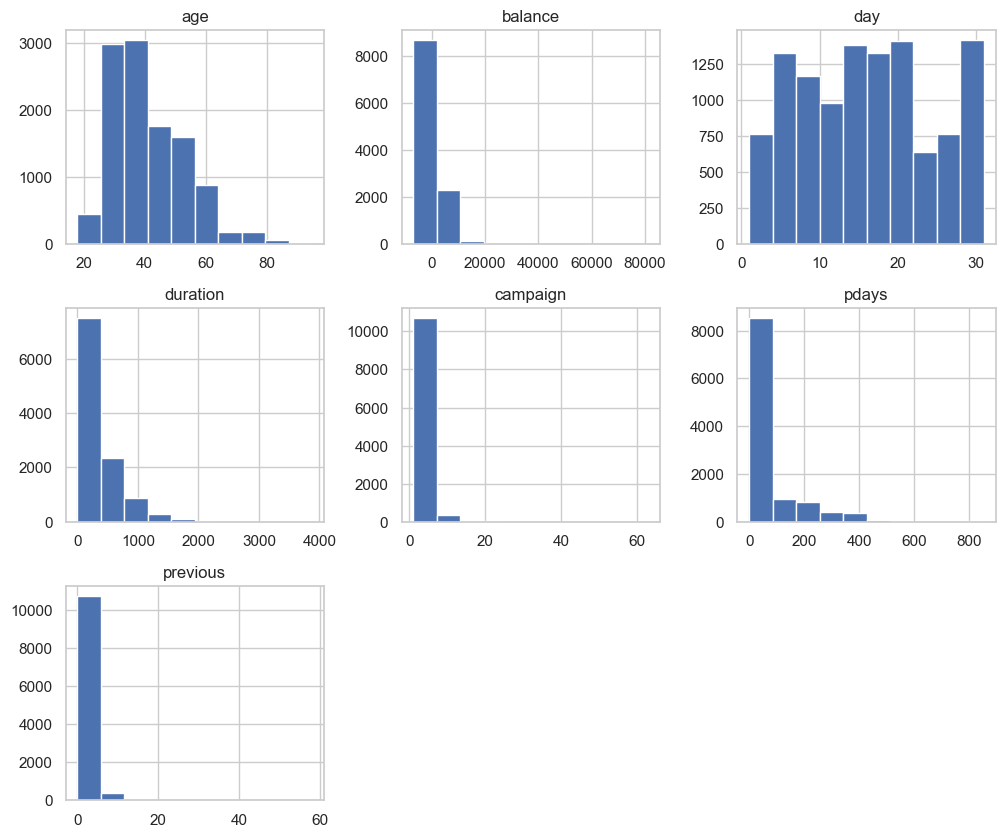

In [82]:
df.hist(figsize=(12,10))
plt.show()

### Distribusi Fitur Kategorikal

Pada tahap ini dilakukan visualisasi terhadap salah satu fitur kategorikal, yaitu **job**, untuk melihat distribusi jenis pekerjaan nasabah dalam dataset.

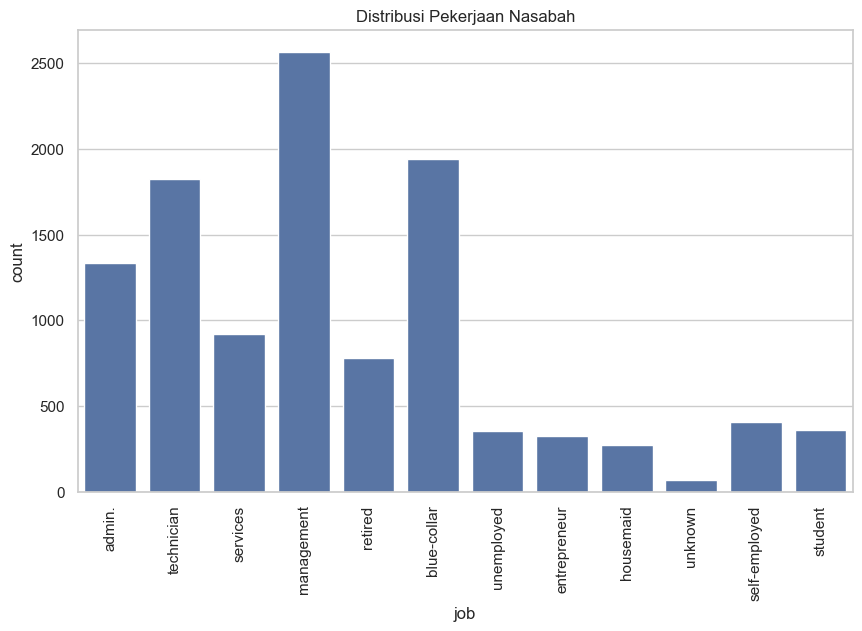

In [83]:
plt.figure(figsize=(10,6))
sns.countplot(x='job', data=df)
plt.xticks(rotation=90)
plt.title("Distribusi Pekerjaan Nasabah")
plt.show()

### Analisis Fitur terhadap Target

Selain melihat distribusi fitur secara individual, penting juga untuk melihat hubungan antara fitur dengan target variable. 

Housing vs Deposit

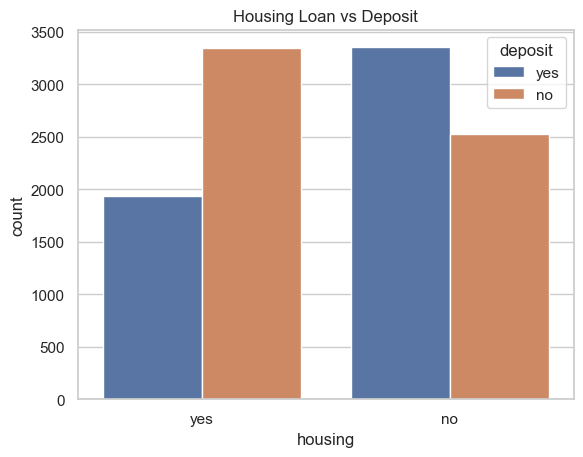

In [84]:
sns.countplot(x='housing', hue='deposit', data=df)
plt.title("Housing Loan vs Deposit")
plt.show()

Loan vs Deposit

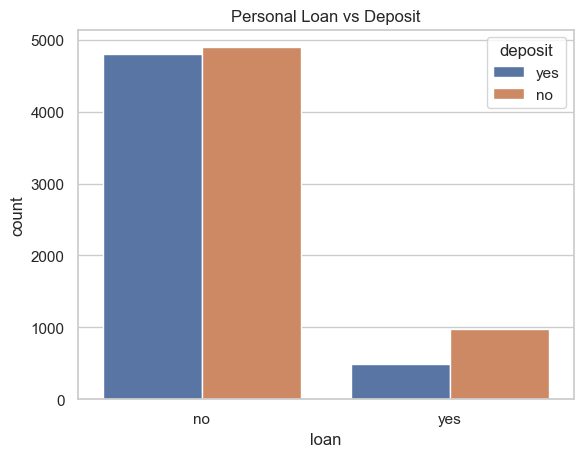

In [85]:
sns.countplot(x='loan', hue='deposit', data=df)
plt.title("Personal Loan vs Deposit")
plt.show()

# **5. Data Preprocessing**

Data preprocessing merupakan tahap penting sebelum data digunakan dalam proses pelatihan model machine learning. Pada tahap ini dilakukan beberapa proses untuk menyiapkan data agar lebih terstruktur dan dapat digunakan oleh algoritma machine learning.

Beberapa tahapan preprocessing yang dilakukan antara lain:

- Mengecek dan menghapus data duplikat
- Melakukan encoding pada target variable
- Melakukan encoding pada fitur kategorikal
- Melakukan normalisasi pada fitur numerik
- Menyimpan dataset hasil preprocessing

Dataset yang telah diproses nantinya akan digunakan pada tahap pembangunan model machine learning.

Mengecek Data Duplikat

In [86]:
df.duplicated().sum()

np.int64(0)

### Encoding Target Variable

Target variable **deposit** memiliki nilai kategorikal yaitu *yes* dan *no*. Nilai tersebut diubah menjadi nilai numerik agar dapat diproses oleh algoritma machine learning.Encoding Target Variable

In [87]:
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

### Encoding Fitur Kategorikal

Fitur yang masih berbentuk kategori perlu diubah menjadi bentuk numerik agar dapat digunakan oleh algoritma machine learning. Proses ini dilakukan menggunakan teknik One-Hot Encoding.

In [88]:
categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = df.astype(int)

### Menyimpan Dataset Hasil Preprocessing

Dataset yang telah melalui tahap preprocessing kemudian disimpan dalam format CSV. Dataset ini akan digunakan pada tahap pembangunan model machine learning.

In [89]:
df.to_csv("../dataset_preprocessing/bank_marketing_clean.csv", index=False)